# PSE vs Conflict with Bootstrap CI

This notebook builds a grouped PSE-vs-conflict plot using bootstrap confidence intervals for data and, when available, for model predictions.

In [1]:
import os
import json
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import loadData
import monteCarloClass

FONT_SIZE_LABEL = 18
FONT_SIZE_TITLE = 20
FONT_SIZE_LEGEND = 16

plt.rcParams.update({
    'font.size': FONT_SIZE_LABEL,
    'axes.labelsize': FONT_SIZE_LABEL,
    'axes.titlesize': FONT_SIZE_TITLE,
    'xtick.labelsize': FONT_SIZE_LABEL - 2,
    'ytick.labelsize': FONT_SIZE_LABEL - 2,
    'legend.fontsize': FONT_SIZE_LEGEND,
    'axes.linewidth': 1.5,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': False,
})

participant_ids = ['as', 'oy', 'dt', 'HH', 'ip', 'ln1', 'ln2', 'mh', 'ml', 'mt', 'qs', 'sx']
parameter_to_plot = 'mu'
models_to_plot = ['lognorm_sharedPrior', 'switchingFree_sharedPrior', 'fusionOnlyLognorm_sharedPrior']
group_bootstrap_resamples = 10000
random_seed = 42


In [2]:
def _safe_json_load(path):
    with open(path, 'r') as f:
        content = f.read().strip()
    return json.loads(content) if content else []


def _participant_csv_name(participant_id):
    return f'{participant_id}_all.csv'


def _candidate_pid_tokens(participant_id):
    return list(dict.fromkeys([participant_id, participant_id.lower(), participant_id.upper()]))


def _resolve_model_bootstrap_path(participant_id, base_model):
    model_name_candidates = {
        'lognorm': ['lognorm_LapseFree_sharedPrior', 'lognorm_sharedPrior', 'lognorm'],
        'switchingFree': ['switchingFree_sharedPrior', 'switchingFree'],
        'fusionOnlyLognorm': ['fusionOnlyLognorm_sharedPrior', 'fusionOnlyLogNorm_sharedPrior', 'fusionOnlyLognorm'],
        'logLinearMismatch': ['logLinearMismatch_sharedPrior', 'logLinearMismatch'],
        'selection': ['selection_sharedPrior', 'selection'],
        'probabilityMatchingLogNorm': ['probabilityMatchingLogNorm_sharedPrior', 'probabilityMatchingLogNorm'],
    }
    for pid_token in _candidate_pid_tokens(participant_id):
        for model_token in model_name_candidates.get(base_model, [base_model]):
            path = os.path.join('bootstrapped_params', pid_token, f'{pid_token}_{model_token}_bootstrapped_params.json')
            if os.path.exists(path):
                return path
    return None


def aggregate_bootstrap_parameter(participant_ids, parameter_to_plot='mu', n_bootstrap=10000, random_seed=42):
    param_index_map = {'lambda': 0, 'mu': 1, 'sigma': 2}
    param_idx = param_index_map[parameter_to_plot]
    rng = np.random.default_rng(random_seed)

    participant_means_by_combo = defaultdict(list)
    contributors_by_combo = defaultdict(set)

    for participant_id in participant_ids:
        boot_path = os.path.join('bootstrapped_params', participant_id, f'{participant_id}_dataFit_bootstrapped_params.json')
        if not os.path.exists(boot_path):
            print(f'Missing data bootstrap for {participant_id}: {boot_path}')
            continue
        data_boots = _safe_json_load(boot_path)
        if not data_boots:
            print(f'Empty data bootstrap for {participant_id}: {boot_path}')
            continue

        data, data_name = loadData.loadData(_participant_csv_name(participant_id), verbose=False)
        mc_fitter = monteCarloClass.OmerMonteCarlo(data)
        mc_fitter.freeP_c = False
        mc_fitter.sharedLambda = True
        mc_fitter.dataName = data_name

        for audio_noise_level in sorted(mc_fitter.uniqueSensory):
            for conflict_level in sorted(mc_fitter.uniqueConflict):
                try:
                    values = [mc_fitter.getParams(boot, conflict_level, audio_noise_level)[param_idx] for boot in data_boots]
                except Exception as e:
                    print(f'Skipping data bootstrap {participant_id} ({conflict_level}, {audio_noise_level}): {e}')
                    continue
                if not values:
                    continue
                key = (audio_noise_level, conflict_level)
                participant_means_by_combo[key].append(float(np.mean(values)))
                contributors_by_combo[key].add(participant_id)

    rows = []
    for (audio_noise_level, conflict_level), participant_means in sorted(participant_means_by_combo.items()):
        arr = np.asarray(participant_means, dtype=float)
        n = len(arr)
        if n == 1:
            ci_lo = ci_hi = float(arr[0])
        else:
            boot_means = np.array([np.mean(rng.choice(arr, size=n, replace=True)) for _ in range(n_bootstrap)])
            ci_lo, ci_hi = np.percentile(boot_means, [2.5, 97.5])
        rows.append({
            'audioNoise': audio_noise_level,
            'conflict': conflict_level,
            'mean': float(np.mean(arr)),
            'std': float(np.std(arr, ddof=1)) if n > 1 else 0.0,
            'sem': float(np.std(arr, ddof=1) / np.sqrt(n)) if n > 1 else 0.0,
            'ci_lo': float(ci_lo),
            'ci_hi': float(ci_hi),
            'n_participants': len(contributors_by_combo[(audio_noise_level, conflict_level)]),
        })
    return pd.DataFrame(rows)


def aggregate_model_predictions_bootstrap(participant_ids, model_types, parameter_to_plot='mu', n_bootstrap=10000, random_seed=42):
    param_index_map = {'lambda': 0, 'mu': 1, 'sigma': 2}
    param_idx = param_index_map[parameter_to_plot]
    rng = np.random.default_rng(random_seed)

    values_by_combo = defaultdict(list)
    bootstrap_means_by_combo = defaultdict(list)
    contributors_by_combo = defaultdict(set)
    bootstrap_contributors_by_combo = defaultdict(set)

    for participant_id in participant_ids:
        data, data_name = loadData.loadData(_participant_csv_name(participant_id), verbose=False)
        mc_fitter = monteCarloClass.OmerMonteCarlo(data)
        mc_fitter.freeP_c = False
        mc_fitter.sharedLambda = True
        mc_fitter.dataName = data_name

        sensory_levels = sorted(mc_fitter.uniqueSensory)
        conflict_levels = sorted(mc_fitter.uniqueConflict)

        for model_type in model_types:
            base_model = model_type.split('_')[0]
            sim_fit_path = os.path.join('psychometric_fits_simulated', participant_id, f'{participant_id}_{base_model}_psychometricFits.json')
            if not os.path.exists(sim_fit_path):
                print(f'Missing simulated fit for {participant_id}, model {base_model}: {sim_fit_path}')
                continue
            sim_fit = _safe_json_load(sim_fit_path)

            model_bootstrap_path = _resolve_model_bootstrap_path(participant_id, base_model)
            model_bootstrap_values = _safe_json_load(model_bootstrap_path) if model_bootstrap_path else []

            for audio_noise_level in sensory_levels:
                for conflict_level in conflict_levels:
                    try:
                        value = mc_fitter.getParams(sim_fit['fitParams'], conflict_level, audio_noise_level)[param_idx]
                    except Exception as e:
                        print(f'Skipping model mean {base_model} for {participant_id} ({conflict_level}, {audio_noise_level}): {e}')
                        continue
                    key = (base_model, audio_noise_level, conflict_level)
                    values_by_combo[key].append(float(value))
                    contributors_by_combo[key].add(participant_id)

                    if model_bootstrap_values:
                        try:
                            boot_vals = [mc_fitter.getParams(boot, conflict_level, audio_noise_level)[param_idx] for boot in model_bootstrap_values]
                        except Exception as e:
                            print(f'Skipping model bootstrap {base_model} for {participant_id} ({conflict_level}, {audio_noise_level}): {e}')
                            boot_vals = []
                        if boot_vals:
                            bootstrap_means_by_combo[key].append(float(np.mean(boot_vals)))
                            bootstrap_contributors_by_combo[key].add(participant_id)

    rows = []
    for key, values in sorted(values_by_combo.items(), key=lambda item: (item[0][1], item[0][2], item[0][0])):
        base_model, audio_noise_level, conflict_level = key
        arr = np.asarray(values, dtype=float)
        bootstrap_arr = np.asarray(bootstrap_means_by_combo.get(key, []), dtype=float)
        has_bootstrap_ci = len(bootstrap_arr) > 0
        if has_bootstrap_ci:
            n_boot = len(bootstrap_arr)
            if n_boot == 1:
                ci_lo = ci_hi = float(bootstrap_arr[0])
            else:
                boot_means = np.array([np.mean(rng.choice(bootstrap_arr, size=n_boot, replace=True)) for _ in range(n_bootstrap)])
                ci_lo, ci_hi = np.percentile(boot_means, [2.5, 97.5])
        else:
            ci_lo = np.nan
            ci_hi = np.nan
        rows.append({
            'model': base_model,
            'audioNoise': audio_noise_level,
            'conflict': conflict_level,
            'mean': float(np.mean(arr)),
            'std': float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0,
            'sem': float(np.std(arr, ddof=1) / np.sqrt(len(arr))) if len(arr) > 1 else 0.0,
            'ci_lo': float(ci_lo) if has_bootstrap_ci else np.nan,
            'ci_hi': float(ci_hi) if has_bootstrap_ci else np.nan,
            'has_bootstrap_ci': bool(has_bootstrap_ci),
            'n_participants': len(contributors_by_combo[key]),
            'n_bootstrap_participants': len(bootstrap_contributors_by_combo.get(key, set())),
        })
    return pd.DataFrame(rows)


def plot_pse_conflict_bootstrap(grouped_data_stats, grouped_model_stats, parameter_to_plot='mu', output_stem='pse_conflict_bootstrap_ci'):
    panel_titles = ['A)  Low auditory noise', 'B)  High auditory noise']
    audio_levels = sorted(grouped_data_stats['audioNoise'].unique().tolist())
    if grouped_model_stats is not None and not grouped_model_stats.empty:
        audio_levels = sorted(set(audio_levels).union(set(grouped_model_stats['audioNoise'].unique())))

    data_colors = {}
    if len(audio_levels) >= 1:
        data_colors[audio_levels[0]] = sns.color_palette('Reds', 8)[5]
    if len(audio_levels) >= 2:
        data_colors[audio_levels[1]] = sns.color_palette('Blues', 8)[5]
    for extra_audio in audio_levels[2:]:
        data_colors[extra_audio] = sns.color_palette('Greys', 8)[5]

    model_display_name_map = {
        'lognorm': 'Causal inference',
        'fusionOnlyLognorm': 'Forced fusion',
        'logLinearMismatch': 'Log-linear mismatch',
        'probabilityMatchingLogNorm': 'Probability matching',
        'selection': 'Causal selection',
        'switchingFree': 'Cue switching',
    }
    model_style_map = {
        'lognorm': {'linestyle': '-', 'marker': 'o'},
        'fusionOnlyLognorm': {'linestyle': '--', 'marker': 's'},
        'switchingFree': {'linestyle': ':', 'marker': '^'},
    }

    model_names = sorted(grouped_model_stats['model'].unique()) if grouped_model_stats is not None and not grouped_model_stats.empty else []
    model_color_lookup = {m: sns.color_palette('tab10', n_colors=max(3, len(model_names)))[i] for i, m in enumerate(model_names)}

    all_series = ['__data__'] + model_names
    offset_span = 15.0
    mid = (len(all_series) - 1) / 2
    series_offsets = {s: (i - mid) * offset_span for i, s in enumerate(all_series)}

    fig, axes = plt.subplots(1, len(audio_levels), figsize=(12, 6), sharey=True)
    if len(audio_levels) == 1:
        axes = [axes]

    from matplotlib.lines import Line2D
    legend_handles = []
    legend_labels = []
    models_added = set()

    for p_idx, (ax, audio_noise) in enumerate(zip(axes, audio_levels)):
        data_color = data_colors[audio_noise]
        subset_data = grouped_data_stats[grouped_data_stats['audioNoise'] == audio_noise].sort_values('conflict')
        if not subset_data.empty:
            x_ms = subset_data['conflict'].to_numpy(dtype=float) * 1000
            y_ms = subset_data['mean'].to_numpy(dtype=float) * 1000
            x_shifted = x_ms + series_offsets['__data__']
            y_lo = subset_data['ci_lo'].to_numpy(dtype=float) * 1000
            y_hi = subset_data['ci_hi'].to_numpy(dtype=float) * 1000
            yerr = np.vstack([y_ms - y_lo, y_hi - y_ms])
            ax.fill_between(x_shifted, y_lo, y_hi, color=data_color, alpha=0.18, linewidth=0, zorder=2)
            ax.plot(x_shifted, y_ms, color=data_color, linewidth=2.2, alpha=0.9, zorder=5)
            ax.errorbar(x_shifted, y_ms, yerr=yerr, color=data_color, fmt='o', capsize=5,
                        linewidth=1.6, capthick=1.3, markerfacecolor='white',
                        markeredgecolor=data_color, markeredgewidth=1.4, zorder=6)
            if p_idx == 0:
                legend_handles.append(Line2D([0], [0], color=data_color, marker='o', markerfacecolor='white', markeredgecolor=data_color, linewidth=2.2, markersize=7, label='Data (low noise)'))
                legend_labels.append('Data (low noise)')
            elif p_idx == 1:
                legend_handles.append(Line2D([0], [0], color=data_color, marker='o', markerfacecolor='white', markeredgecolor=data_color, linewidth=2.2, markersize=7, label='Data (high noise)'))
                legend_labels.append('Data (high noise)')

        for model_name in model_names:
            subset_model = grouped_model_stats[(grouped_model_stats['audioNoise'] == audio_noise) & (grouped_model_stats['model'] == model_name)].sort_values('conflict')
            if subset_model.empty:
                continue
            display_name = model_display_name_map.get(model_name, model_name)
            color = model_color_lookup[model_name]
            ls = model_style_map.get(model_name, {}).get('linestyle', '-')
            mk = model_style_map.get(model_name, {}).get('marker', 'o')
            x_ms = subset_model['conflict'].to_numpy(dtype=float) * 1000
            x_shifted = x_ms + series_offsets[model_name]
            means_ms = subset_model['mean'].to_numpy(dtype=float) * 1000
            has_bootstrap_ci = bool(subset_model['has_bootstrap_ci'].fillna(False).any()) if 'has_bootstrap_ci' in subset_model.columns else False
            if has_bootstrap_ci and subset_model['ci_lo'].notna().all() and subset_model['ci_hi'].notna().all():
                y_lo = subset_model['ci_lo'].to_numpy(dtype=float) * 1000
                y_hi = subset_model['ci_hi'].to_numpy(dtype=float) * 1000
                yerr = np.vstack([means_ms - y_lo, y_hi - means_ms])
                ax.fill_between(x_shifted, y_lo, y_hi, color=color, alpha=0.10, linewidth=0, zorder=1)
                ax.errorbar(x_shifted, means_ms, yerr=yerr, color=color, linestyle=ls, marker=mk,
                            markerfacecolor='white', markeredgewidth=1.3, capsize=4,
                            linewidth=2.0, zorder=4)
            else:
                ax.plot(x_shifted, means_ms, color=color, linestyle=ls, marker=mk,
                        markerfacecolor='white', markeredgewidth=1.3,
                        linewidth=2.0, markersize=7, zorder=4)
            if model_name not in models_added:
                legend_handles.append(Line2D([0], [0], color=color, linestyle=ls, marker=mk, markerfacecolor='white', markeredgewidth=1.3, linewidth=2.0, markersize=7, label=display_name))
                legend_labels.append(display_name)
                models_added.add(model_name)

        title = panel_titles[p_idx] if p_idx < len(panel_titles) else f'Panel {p_idx + 1}'
        ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
        ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
        ax.set_title(title, fontsize=FONT_SIZE_TITLE, loc='left', pad=12)
        ax.set_xticks([-250, -170, -80, 0, 80, 170, 250])
        ax.set_xticklabels([str(t) for t in [-250, -170, -80, 0, 80, 170, 250]])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axes[0].set_ylabel('PSE shift (ms)', fontsize=FONT_SIZE_LABEL)
    fig.supxlabel('Cue conflict (ms)', fontsize=FONT_SIZE_LABEL, x=0.5, y=0.10)
    legend_handles.append(Line2D([], [], color='none', label='Shaded regions show bootstrap 95% CI when bootstrap files are available'))
    legend_labels.append('Shaded regions show bootstrap 95% CI when bootstrap files are available')
    fig.legend(legend_handles, legend_labels, loc='lower center', bbox_to_anchor=(0.5, -0.03), ncol=3, frameon=True, edgecolor='black', fancybox=False)
    plt.tight_layout(rect=(0, 0.13, 1, 1))
    plt.savefig(f'{output_stem}.png', dpi=250)
    plt.savefig(f'{output_stem}.pdf', dpi=900)
    plt.show()


Grouped data rows: 14
Grouped model rows: 42

Model bootstrap coverage:
                   has_bootstrap_ci  n_bootstrap_participants  n_participants
model                                                                        
fusionOnlyLognorm             False                         0              12
lognorm                        True                         2              12
switchingFree                 False                         0              12


ValueError: 'yerr' must not contain negative values

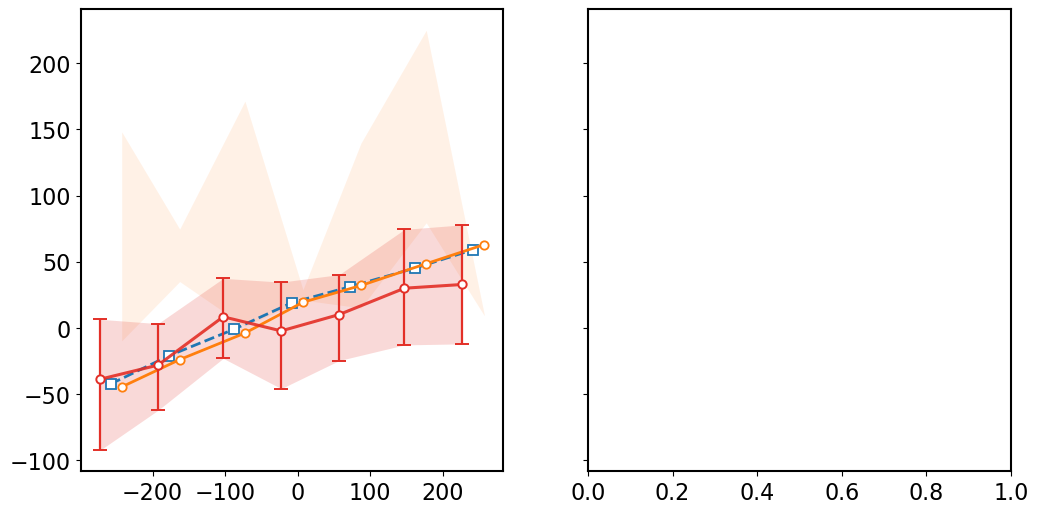

In [3]:
grouped_data_stats = aggregate_bootstrap_parameter(
    participant_ids,
    parameter_to_plot=parameter_to_plot,
    n_bootstrap=group_bootstrap_resamples,
    random_seed=random_seed,
)

grouped_model_stats = aggregate_model_predictions_bootstrap(
    participant_ids,
    model_types=models_to_plot,
    parameter_to_plot=parameter_to_plot,
    n_bootstrap=group_bootstrap_resamples,
    random_seed=random_seed,
)

print('Grouped data rows:', len(grouped_data_stats))
print('Grouped model rows:', len(grouped_model_stats))
if not grouped_model_stats.empty:
    print('\nModel bootstrap coverage:')
    print(grouped_model_stats.groupby('model')[['has_bootstrap_ci', 'n_bootstrap_participants', 'n_participants']].max())

plot_pse_conflict_bootstrap(
    grouped_data_stats,
    grouped_model_stats,
    parameter_to_plot=parameter_to_plot,
    output_stem='pse_conflict_bootstrap_ci',
)
